<a href="https://colab.research.google.com/github/Rastaffari68/MLDS6/blob/Experimento%2F-XGBoost/docs/data/MARTIN_ZORRILLA_ASRS_Proyecto_Ciclo_Vida_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto: Clasificación de Problemas en Reportes de Seguridad Aérea (ASRS)**
---

> El sistema de reporte voluntario de seguridad aérea de la NASA (ASRS — Aviation Safety Reporting System) recopila, desde 1976, reportes anónimos de pilotos, controladores de tránsito aéreo y otros actores de la industria aeronáutica. Cada reporte describe un incidente o condición potencialmente insegura, junto con metadatos estructurados como la fase de vuelo, las condiciones meteorológicas, el tipo de aeronave, la anomalía detectada y una evaluación del problema primario.

> Este proyecto aplica técnicas de ciencia de datos para construir un modelo de clasificación automática del **problema primario** de cada reporte, a partir de variables estructuradas del dataset. El ciclo de vida completo incluye entendimiento del negocio, exploración de datos, preparación, modelamiento con XGBoost, optimización de hiperparámetros con Optuna, seguimiento de experimentos con MLflow y registro del modelo para despliegue.

## **PRIMERA ENTREGA**
# **1. Entendimiento del Negocio y Carga de Datos**
---

### **1.1. Trasfondo del Negocio**
---

> El ASRS opera bajo un principio de inmunidad regulatoria: quienes reportan incidentes no reciben sanciones de la FAA, lo que incentiva la transparencia. Esto convierte al dataset en una fuente excepcionalmente rica y honesta sobre los factores reales que generan situaciones de riesgo en la aviación.

> **Origen del conjunto de datos:** este dataset es una muestra de los reportes de aviación general disponibles en la base de datos oficial del ASRS, accesible en [https://asrs.arc.nasa.gov/search/database.html](https://asrs.arc.nasa.gov/search/database.html). La muestra comprende los reportes registrados entre el **1 de enero de 2006** y el **31 de diciembre de 2006**, lo que la convierte en una fotografía representativa de los incidentes de aviación general ocurridos durante ese año.

> La columna que pretendemos escoger como objetivo (`Primary Problem`) clasifica cada incidente en categorías como **Human Factors** (factores humanos), **Aircraft** (fallas de aeronave), **Procedure** (procedimientos), **Weather** (clima), entre otras. Esta clasificación es crítica para que las organizaciones de seguridad aérea prioricen intervenciones y asignen recursos.

> El problema de negocio es el siguiente: **¿puede un modelo de machine learning, entrenado sobre variables estructuradas de los reportes, predecir automáticamente la categoría del problema primario?** Una solución así permitiría agilizar la clasificación de nuevos reportes y apoyar la detección temprana de patrones de riesgo.

### **1.2. Alcance**
---

El proyecto cubre las siguientes etapas:

* Carga y exploración del dataset ASRS (4,434 reportes, 125 columnas con estructura jerárquica)
* Selección y preparación de features estructuradas (sin texto libre en esta fase)
* Simplificación del target a 3 clases: **Human Factors**, **Aircraft**, **Other**
* Entrenamiento de un clasificador XGBoost
* Optimización de hiperparámetros con Optuna
* Seguimiento de experimentos con MLflow (todos los commits quedan registrados)
* Versionado y registro del mejor modelo para despliegue

**Variables seleccionadas como features:**

| Feature | Grupo | Nulos |
|---|---|---|
| Flight Phase | Aircraft 1 | 0.6% |
| Flight Conditions | Environment | 12.3% |
| Light | Environment | 11.3% |
| Anomaly | Events | 0.2% |
| Contributing Factors | Assessments | 0.3% |
| Result | Events | 2.9% |
| Make Model Name | Aircraft 1 | 0.2% |
| Operating Under FAR Part | Aircraft 1 | 2.1% |
| Detector | Events | 2.8% |

### **1.3. Instalación de Dependencias**
---

In [1]:
!pip install mlflow==2.17.1 optuna optuna-dashboard xgboost scikit-learn pyngrok -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 901.4/901.4 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/

### **1.4. Carga de Datos**
---

> El dataset ASRS tiene una estructura de encabezado doble (dos filas de headers en el CSV). La primera fila corresponde al grupo temático (Time, Place, Environment, Aircraft 1, etc.) y la segunda al nombre específico del campo. Se usa `header=[0,1]` para capturar ambos niveles.

In [2]:
import os
import warnings
import mlflow
import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from IPython import get_ipython

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


In [3]:
# ── Carga del dataset desde GitHub ────────────────────────────────────────────
import pandas as pd

RAW_URL = "https://raw.githubusercontent.com/Rastaffari68/MLDS6/master/docs/data/ASRS_Dataset.csv"

df_raw = pd.read_csv(RAW_URL, header=[0, 1], low_memory=False)

print(f'Dimensiones del dataset: {df_raw.shape}')
print(f'Total de reportes: {df_raw.shape[0]:,}')
print(f'Total de columnas: {df_raw.shape[1]}')
df_raw.head(3)

Dimensiones del dataset: (4434, 125)
Total de reportes: 4,434
Total de columnas: 125


Time                              Place                  \
        ACN      Date Local Time Of Day Locale Reference State Reference   
0       NaN       NaN               NaN              NaN             NaN   
1  643525.0  200501.0         0601-1200      ZZZ.Airport              US   
2  643757.0  200501.0         1201-1800      FCH.Airport              CA   

                                                                            \
  Relative Position.Angle.Radial Relative Position.Distance.Nautical Miles   
0                            NaN                                       NaN   
1                            NaN                                       NaN   
2                            NaN                                       NaN   

                                                       \
  Altitude.AGL.Single Value Altitude.MSL.Single Value   
0                       NaN                       NaN   
1                       NaN                    1900.0   
2                       NaN                     960.0   

                              ...              Events                \
  Latitude / Longitude (UAS)  ...            Detector When Detected   
0                        NaN  ...                 NaN           NaN   
1                        NaN  ...                 NaN           NaN   
2                        NaN  ...  Person Flight Crew           NaN   

                                                      \
                                              Result   
0                                                NaN   
1  Air Traffic Control Issued Advisory / Alert; F...   
2  Flight Crew Executed Go Around / Missed Approa...   

                         Assessments                  \
   Contributing Factors / Situations Primary Problem   
0                                NaN             NaN   
1            Aircraft; Human Factors        Aircraft   
2  Human Factors; Airspace Structure   Human Factors   

                                            Report 1           Report 2  \
                                           Narrative Callback Narrative   
0                                                NaN      NaN       NaN   
1  I WAS CONDUCTING AN IFR CROSS COUNTRY TRAINING...      NaN       NaN   
2  I WAS PRACTICING IFR APCHS TODAY IN FRESNO; CA...      NaN       NaN   

                                                     Report 1  
  Callback                                           Synopsis  
0      NaN                                                NaN  
1      NaN  BE33 FOLLOWS ON GLIDE PATH INDICATION 500 FT B...  
2      NaN  BE36 PLT EXPRESSES CONCERN REGARDING POTENTIAL...  

[3 rows x 125 columns]

### **1.5. Configuración del Servidor MLflow**
---

> MLflow registrará **todos los experimentos** realizados durante el proyecto: cada prueba de hiperparámetros, cada modelo entrenado y sus métricas. Esto permite reproducibilidad completa y auditoría de decisiones.

In [4]:
#
command = """
mlflow server \
        --backend-store-uri sqlite:///asrs_tracking.db \
        --default-artifact-root file:asrs_mlruns \
        -p 5000 &
"""
get_ipython().system_raw(command)
print('Servidor MLflow iniciado en http://localhost:5000')

Servidor MLflow iniciado en http://localhost:5000


In [30]:
from google.colab import userdata
import os

os.environ["NGROK_TOKEN"] = userdata.get("NGROK_TOKEN")
!ngrok authtoken $NGROK_TOKEN

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok
ngrok.connect(5000, "http", host_header="localhost")

In [9]:
# ── Configurar tracking URI y crear experimento ────────────────────────────────
mlflow.set_tracking_uri("http://localhost:5000")

EXPERIMENT_NAME = "ASRS_Classification"
try:
    exp_id = mlflow.create_experiment(
        name=EXPERIMENT_NAME,
        artifact_location="asrs_mlruns"
    )
except Exception:
    exp_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

print(f'Experimento: {EXPERIMENT_NAME} | ID: {exp_id}')

Experimento: ASRS_Classification | ID: 1


---
## **2. Exploración de Datos (EDA)**
---

### **2.1. Resumen General del Dataset**
---

> El dataset ASRS contiene **4,434 reportes** organizados en **125 columnas** agrupadas en categorías temáticas: Time, Place, Environment, Aircraft 1, Aircraft 2, Component, Person 1, Person 2, Events y Assessments. Las columnas de mayor interés para la clasificación pertenecen a los grupos Environment, Aircraft 1, Events y Assessments.

In [10]:
# ── Resumen de nulos por columna  ───────────────────────
null_pct = (df_raw.isnull().mean() * 100).sort_values()
null_pct_filtered = null_pct[null_pct < 50]

print(f'Columnas con menos del 50% de nulos: {len(null_pct_filtered)} de {len(null_pct)}')
print()
print(null_pct_filtered.to_string())

Columnas con menos del 50% de nulos: 33 de 125

             ACN                                     0.022553
Time         Date                                    0.022553
Aircraft 1   Mission                                 0.022553
Report 1     Synopsis                                0.022553
             Narrative                               0.022553
Person 1     ASRS Report Number.Accession Number     0.112765
Events       Anomaly                                 0.157871
Aircraft 1   Make Model Name                         0.157871
Assessments  Primary Problem                         0.315742
             Contributing Factors / Situations       0.315742
Aircraft 1   Flight Phase                            0.586378
Person 1     Location Of Person                      1.059991
Place        State Reference                         1.556157
Person 1     Function                                1.578710
             Qualification                           1.578710
Place        Locale Re

### **2.2. Estrategia ante Datos Faltantes**
---

> El análisis de valores nulos revela que una parte importante de las columnas del dataset presenta información incompleta, con porcentajes que van desde menos del 1% hasta casi el 50%. Dado que muchas variables tienen una proporción de nulos que compromete su utilidad estadística, **no se utilizará la totalidad de las columnas disponibles** para construir el modelo.

> En su lugar, se adoptará un enfoque de **selección manual basada en criterio experto**: se escogerá un subconjunto reducido de variables cuya relevancia operacional para la clasificación de incidentes de aviación esté respaldada por conocimiento del dominio. Esta decisión garantiza que el modelo sea entrenado con features de calidad suficiente, minimizando el ruido introducido por columnas con alta proporción de datos ausentes.

> Los criterios de selección son los siguientes:
> * La variable debe tener **menos del 25% de valores nulos**
> * Debe tener **relevancia operacional directa** con el tipo de problema reportado (fase de vuelo, condiciones ambientales, tipo de aeronave, anomalía detectada, etc.)
> * No debe ser una variable derivada del target ni introducir fuga de información (*data leakage*)

> Los valores faltantes en las variables seleccionadas serán imputados con la etiqueta `'Unknown'` antes del proceso de codificación, preservando la integridad del dataset sin eliminar registros.

### **2.3. Análisis del Target: Primary Problem**
---

> La variable objetivo `Primary Problem` presenta una distribución fuertemente desbalanceada. La categoría **Human Factors** concentra el 62.8% de los reportes, lo que refleja la realidad operacional de la aviación: la mayoría de los incidentes involucran error humano. Las categorías minoritarias serán agrupadas en **Other** para facilitar el modelamiento.

Distribución de Primary Problem:
(Assessments, Primary Problem)
Human Factors                               2782
Aircraft                                     609
Ambiguous                                    383
Procedure                                    321
Weather                                       76
Environment - Non Weather Related             62
Airport                                       60
Airspace Structure                            53
ATC Equipment / Nav Facility / Buildings      26
Company Policy                                19
Chart Or Publication                          18
Staffing                                       7
Equipment / Tooling                            3
Manuals                                        1


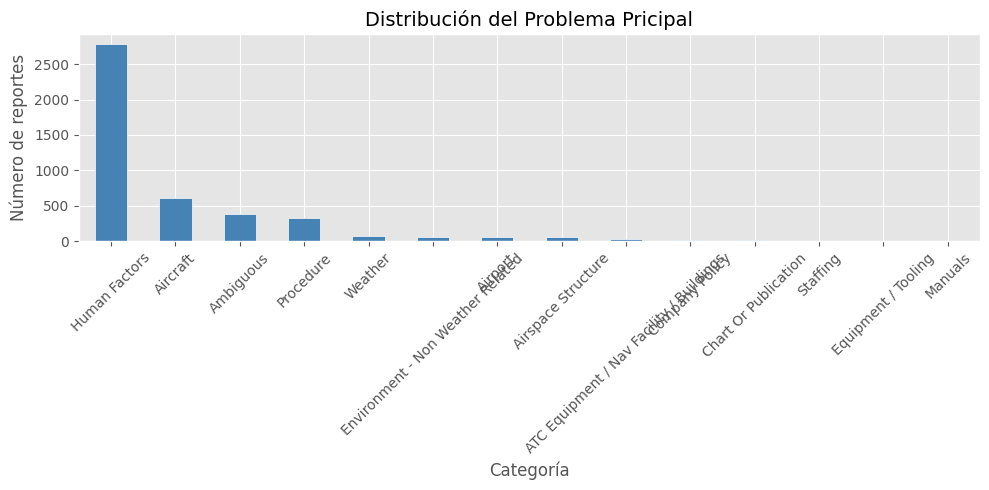

In [11]:
target_col = ('Assessments', 'Primary Problem')
vc = df_raw[target_col].value_counts()

print('Distribución de Primary Problem:')
print(vc.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
vc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribución del Problema Pricipal', fontsize=14)
ax.set_xlabel('Categoría')
ax.set_ylabel('Número de reportes')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### **2.3. Análisis de Caracteristicas Clave**
---

#### **Flight Phase — Fase de Vuelo**
---

> La fase de vuelo es una de las variables más relevantes en el análisis de seguridad aérea. La literatura especializada en factores humanos y accidentología aeronáutica establece consistentemente que el riesgo no se distribuye de manera uniforme a lo largo de un vuelo: las fases de **aproximación, aterrizaje y despegue** concentran la mayor proporción de incidentes y accidentes, a pesar de representar una fracción mínima del tiempo total de vuelo.

> Esta variable permite contextualizar **en qué momento operacional ocurrió el incidente**, lo que tiene implicaciones directas sobre el tipo de problema primario. Por ejemplo, un incidente durante **Landing** tiende a estar asociado con errores de juicio o condiciones de pista, mientras que uno durante **Cruise** puede estar más relacionado con fallas de equipos o desorientación espacial.

> Como se observa en el gráfico, **Landing** domina ampliamente el dataset con cerca de 2,000 reportes, seguido de **Initial Approach** y **Final Approach**. Esto confirma el patrón conocido en la industria como la *regla del 80%*: la gran mayoría de los accidentes ocurren en las fases terminales del vuelo, cuando la carga de trabajo de la tripulación es máxima y los márgenes de error son mínimos.

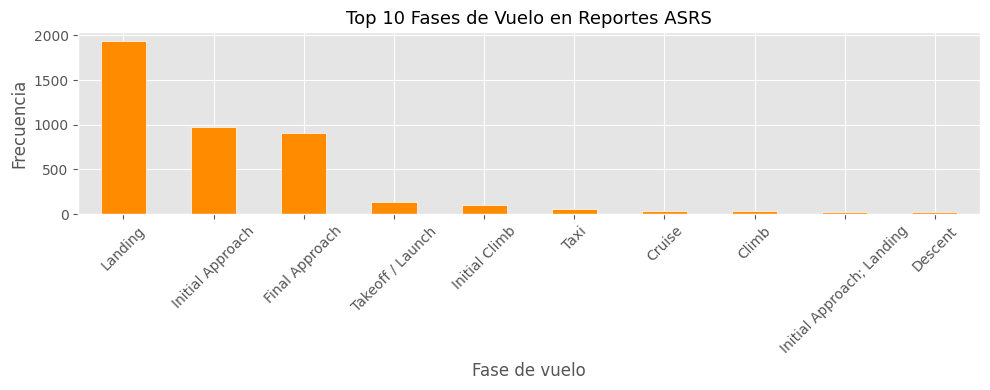

(Aircraft 1, Flight Phase)
Landing                      1937
Initial Approach              974
Final Approach                902
Takeoff / Launch              138
Initial Climb                 106
Taxi                           59
Cruise                         33
Climb                          32
Initial Approach; Landing      28
Descent                        27


In [12]:
# ── Distribución de Flight Phase ──────────────────────────────────────────────
flight_phase_col = ('Aircraft 1', 'Flight Phase')
fp_vc = df_raw[flight_phase_col].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 4))
fp_vc.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('Top 10 Fases de Vuelo en Reportes ASRS', fontsize=13)
ax.set_xlabel('Fase de vuelo')
ax.set_ylabel('Frecuencia')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(fp_vc.to_string())

#### **Flight Conditions y Light — Condiciones Ambientales**
---

> Estas dos variables capturan el **entorno visual** en el que ocurrió el incidente, y son fundamentales para entender el contexto operacional del piloto en el momento del evento.

> **Flight Conditions** distingue entre vuelo en condiciones meteorológicas visuales (**VMC**) e instrumentales (**IMC**). Como se observa en el gráfico, la gran mayoría de los incidentes ocurrieron en VMC, lo que puede parecer contraintuitivo pero refleja un patrón bien documentado: los pilotos tienden a sobrestimar sus capacidades en condiciones aparentemente favorables, relajando su nivel de alerta.

> **Light** indica si el incidente ocurrió de día, de noche, al amanecer o al atardecer. La luz diurna domina el dataset, nuevamente por el mayor volumen de operaciones durante el día. Sin embargo, los incidentes nocturnos tienen un perfil de riesgo distinto, asociado con mayor frecuencia a desorientación espacial y pérdida de referencias visuales externas.

> Ambas variables son relevantes para el modelo porque el tipo de problema primario puede variar significativamente según las condiciones ambientales: un incidente en IMC nocturno tiende a estar más ligado a factores de aeronave o procedimiento, mientras que uno en VMC diurno suele involucrar factores humanos como distracción o falta de conciencia situacional.

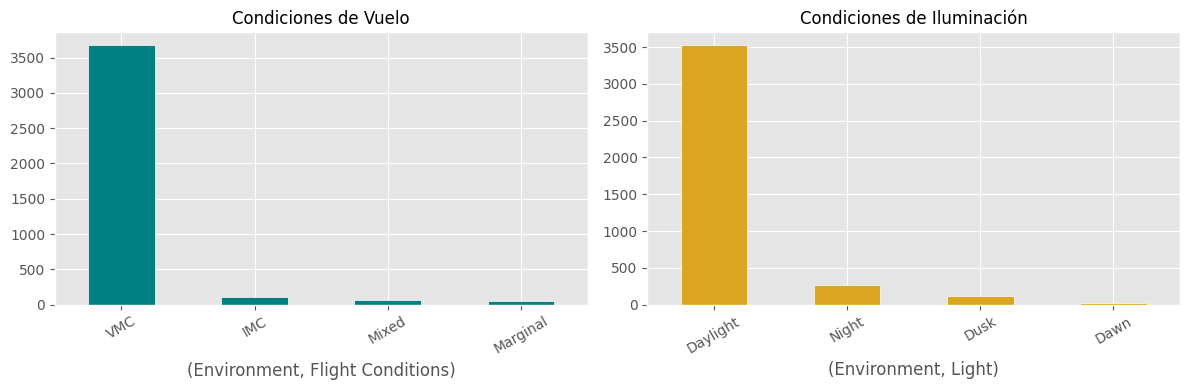

In [13]:
# ── Distribución de Flight Conditions ─────────────────────────────────────────
fc_col = ('Environment', 'Flight Conditions')
fc_vc = df_raw[fc_col].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fc_vc.plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Condiciones de Vuelo', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

light_col = ('Environment', 'Light')
light_vc = df_raw[light_col].value_counts()
light_vc.plot(kind='bar', ax=axes[1], color='goldenrod', edgecolor='white')
axes[1].set_title('Condiciones de Iluminación', fontsize=12)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

#### **Anomaly — Tipo de Anomalía Reportada**
---

> La variable `Anomaly` describe el **tipo de evento anómalo** que motivó el reporte. Es posiblemente la variable más informativa del dataset desde el punto de vista operacional, ya que caracteriza directamente la naturaleza del incidente.

> Como se observa en el gráfico, **Conflict NMAC** (Near Mid-Air Collision — casi colisión en el aire) domina ampliamente con más de 500 reportes, seguido de combinaciones que involucran desviaciones de procedimiento y conflictos en tierra. Esto es consistente con el período analizado (2006), cuando el espacio aéreo de aviación general presentaba alta densidad de tráfico sin los sistemas de vigilancia actuales.

> Es importante notar que en su estado original esta variable contiene **múltiples anomalías separadas por punto y coma** en una misma celda, lo que refleja que un solo incidente puede involucrar varios tipos de eventos simultáneamente. Como parte del preprocesamiento, se conservará únicamente el **primer valor registrado**, que representa la anomalía principal del evento.

> Su inclusión en el modelo es clave porque existe una relación directa entre el tipo de anomalía y el problema primario: un `Aircraft Equipment Problem Critical` apunta naturalmente hacia un problema de aeronave, mientras que un `Conflict NMAC` suele estar asociado a factores humanos o de procedimiento.

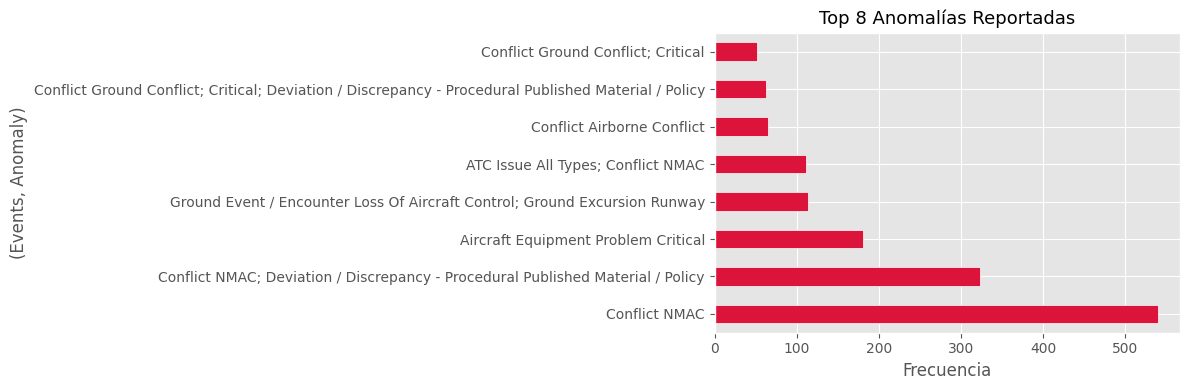

In [14]:
# ── Top anomalías reportadas ───────────────────────────────────────────────────
anomaly_col = ('Events', 'Anomaly')
anomaly_vc = df_raw[anomaly_col].value_counts().head(8)

fig, ax = plt.subplots(figsize=(12, 4))
anomaly_vc.plot(kind='barh', ax=ax, color='crimson', edgecolor='white')
ax.set_title('Top 8 Anomalías Reportadas', fontsize=13)
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.show()

---
## **TERCERA ENTREGA**
## **3. Preparación de Datos**
---

### **3.1. Selección de Columnas**
---

> Se seleccionan las columnas con menos del 25% de nulos y con relevancia operacional para la clasificación. Las columnas de texto libre (`Narrative`, `Synopsis`) se reservan para una fase posterior de NLP.

In [15]:
# ── Definición de features y target ───────────────────────────────────────────
FEATURE_COLS = [
    ('Aircraft 1', 'Flight Phase'),
    ('Environment', 'Flight Conditions'),
    ('Environment', 'Light'),
    ('Events', 'Anomaly'),
    ('Assessments', 'Contributing Factors / Situations'),
    ('Events', 'Result'),
    ('Aircraft 1', 'Make Model Name'),
    ('Aircraft 1', 'Operating Under FAR Part'),
    ('Events', 'Detector'),
]

TARGET_COL = ('Assessments', 'Primary Problem')

df_work = df_raw[FEATURE_COLS + [TARGET_COL]].copy()
df_work.columns = [
    'flight_phase', 'flight_conditions', 'light',
    'anomaly', 'contributing_factors', 'result',
    'make_model', 'far_part', 'detector', 'primary_problem'
]

print(f'Dataset de trabajo: {df_work.shape}')
df_work.head(3)

Dataset de trabajo: (4434, 10)


,flight_phase,flight_conditions,light,anomaly,contributing_factors,result,make_model,far_part,detector,primary_problem
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Initial Approach; Landing,IMC,Daylight,Aircraft Equipment Problem Critical; Deviation...,Aircraft; Human Factors,Air Traffic Control Issued Advisory / Alert; F...,Bonanza 33,Part 91,NaN,Aircraft
2,Landing; Initial Approach,IMC,Daylight,Conflict Airborne Conflict; Deviation / Discre...,Human Factors; Airspace Structure,Flight Crew Executed Go Around / Missed Approa...,Bonanza 36,Part 91,Person Flight Crew,Human Factors


### **3.2. Simplificación del Target (2 clases)**
---

> Para facilitar el modelamiento y mejorar la calidad de las predicciones, se agrupan las categorías minoritarias en **Other**. Las tres clases resultantes representan el 90% del dataset original.

Distribución del target simplificado:
target
Human Factors    2782
Other            1638
Name: count, dtype: int64

Total de registros tras limpieza: 4,420


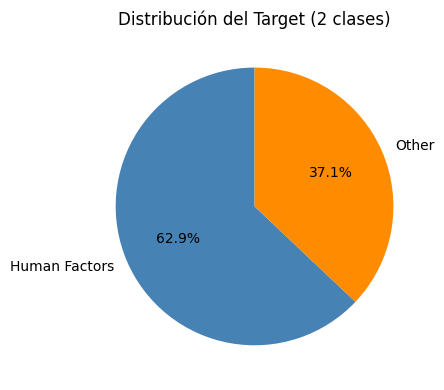

In [16]:
# ── Simplificación del Target (2 clases) ─────────────────────────────────

def simplify_target(val):
    if pd.isna(val):
        return None
    if val == 'Human Factors':
        return 'Human Factors'
    else:
        return 'Other'  # Aircraft + todo lo demás → Other

df_work['target'] = df_work['primary_problem'].apply(simplify_target)
df_work = df_work.dropna(subset=['target'])

print('Distribución del target simplificado:')
print(df_work['target'].value_counts())
print()
print(f'Total de registros tras limpieza: {len(df_work):,}')

# Visualización
fig, ax = plt.subplots(figsize=(6, 4))
df_work['target'].value_counts().plot(kind='pie', ax=ax, autopct='%1.1f%%',
                                       colors=['steelblue', 'darkorange'],
                                       startangle=90)
ax.set_title('Distribución del Target (2 clases)', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### **3.3. Codificación de Variables Categóricas**
---

> Todas las variables seleccionadas son de naturaleza categórica, por lo que requieren ser transformadas a formato numérico antes de ser procesadas por el modelo. Este proceso se realiza en tres pasos:

> **1. Imputación de nulos:** los valores faltantes en cada variable (bien sea feature o target) se eliminan.

> **2. Extracción del primer factor:** las variables `Flight Phase`, `Anomaly`, `Contributing Factors` y `Result` pueden contener múltiples valores separados por punto y coma en una misma celda. Para reducir la alta cardinalidad que esto genera, se conserva únicamente el **primer valor registrado**, que representa el factor principal del incidente según el criterio del reportante.

> **3. Label Encoding:** una vez limpia cada variable, se aplica codificación de etiquetas (`LabelEncoder`) que asigna un número entero a cada categoría única. Esta técnica es compatible con XGBoost y permite al modelo operar sobre representaciones numéricas sin asumir orden ni jerarquía entre categorías.

In [17]:
# ── Codificación de Variables Categóricas ────────────────────────────────

# make_model se elimina: alta cardinalidad, poco valor predictivo
FEATURE_NAMES = [
    'flight_phase', 'flight_conditions', 'light',
    'anomaly', 'contributing_factors', 'result',
    'far_part', 'detector'
]

df_encoded = df_work[FEATURE_NAMES + ['target']].copy()

# Eliminar filas con CUALQUIER valor faltante en features o target
# (en lugar de imputar con 'Unknown')
before = len(df_encoded)
df_encoded = df_encoded.dropna(subset=FEATURE_NAMES + ['target'])
after = len(df_encoded)
print(f'Registros eliminados por nulos: {before - after} ({(before-after)/before*100:.1f}%)')
print(f'Registros restantes: {after:,}')

# Tomar solo el primer factor en variables con múltiples valores separados por ";"
cols_multivalor = ['flight_phase', 'anomaly', 'contributing_factors', 'result']
for col in cols_multivalor:
    df_encoded[col] = df_encoded[col].apply(
        lambda x: x.split(';')[0].strip()
    )

# Label Encoding de features
label_encoders = {}
for col in FEATURE_NAMES:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# Codificación del target
le_target = LabelEncoder()
df_encoded['target_enc'] = le_target.fit_transform(df_encoded['target'])

print('\nClases del target:')
for i, cls in enumerate(le_target.classes_):
    print(f'  {i} → {cls}')

print(f'\nDataset codificado: {df_encoded.shape}')
df_encoded.head(3)

Registros eliminados por nulos: 999 (22.6%)
Registros restantes: 3,421

Clases del target:
  0 → Human Factors
  1 → Other

Dataset codificado: (3421, 10)


,flight_phase,flight_conditions,light,anomaly,contributing_factors,result,far_part,detector,target,target_enc
2,6,0,1,4,8,8,12,37,Human Factors,0
3,6,3,1,6,8,26,12,37,Human Factors,0
4,4,3,1,1,0,18,12,37,Other,1


### **3.4. División Train / Test**
---

In [18]:
X = df_encoded[FEATURE_NAMES].values
y = df_encoded['target_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} registros')
print(f'Test:  {X_test.shape[0]:,} registros')

Train: 2,394 registros
Test:  1,027 registros


---
## **CUARTA ENTREGA**
## **4. Modelamiento con distintas aproximaciones**
---

> Cada función de entrenamiento y evaluación registra es reportada con diferentes modelos.

# 4.1 Modelamiento — Random Forest

## Descripción
Random Forest es un algoritmo de ensamble que construye múltiples árboles
de decisión de forma paralela e independiente, combinando sus predicciones
por votación mayoritaria. Es robusto ante el sobreajuste y funciona bien
con variables categóricas codificadas numéricamente.

## Parámetros utilizados

| Parámetro | Valor | Descripción |
|---|---|---|
| `n_estimators` | 100 | Número de árboles en el bosque |
| `max_depth` | 8 | Profundidad máxima de cada árbol |
| `random_state` | 42 | Reproducibilidad |
| `n_jobs` | -1 | Usa todos los núcleos disponibles |
| `class_weight` | balanced | Ajusta pesos inversamente proporcional a la frecuencia de cada clase |

## Manejo del desbalance
El dataset presenta un desbalance moderado (~63% Human Factors vs ~37% Other).
El parámetro `class_weight='balanced'` corrige esto automáticamente asignando
mayor peso a la clase minoritaria (Other) durante el entrenamiento, evitando
que el modelo se sesgue hacia la clase mayoritaria.

## Métrica principal
Se utiliza **F1 Macro** como métrica de comparación entre modelos,
ya que pondera por igual ambas clases independientemente de su frecuencia.

✅ Modelo entrenado.

F1 Macro:  0.7095
Accuracy:  0.7352

Reporte de clasificación:
               precision    recall  f1-score   support

Human Factors       0.78      0.81      0.80       656
        Other       0.64      0.61      0.62       371

     accuracy                           0.74      1027
    macro avg       0.71      0.71      0.71      1027
 weighted avg       0.73      0.74      0.73      1027



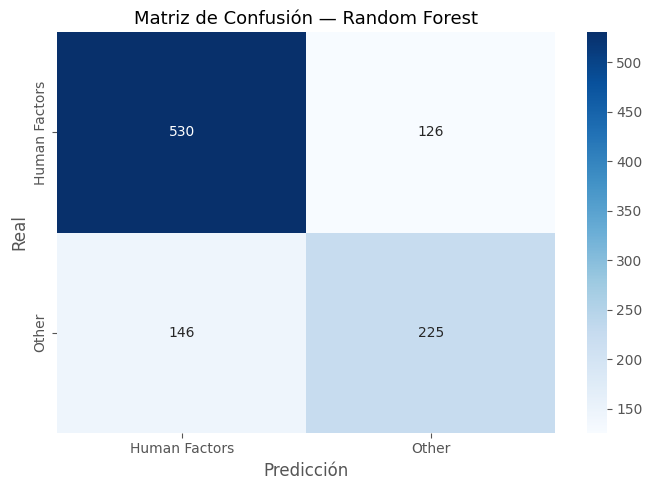

In [19]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#  Entrenar ─────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'   # ← esto es todo
)
rf.fit(X_train, y_train)
print("✅ Modelo entrenado.")

# Evaluar ──────────────────────────────────────────────────────
y_pred_rf = rf.predict(X_test)

f1  = f1_score(y_test, y_pred_rf, average='macro')
acc = accuracy_score(y_test, y_pred_rf)

print(f"\nF1 Macro:  {f1:.4f}")
print(f"Accuracy:  {acc:.4f}")

#  Reporte de clasificación ─────────────────────────────────────
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))

# Matriz de confusión ──────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_, ax=ax)
ax.set_title('Matriz de Confusión — Random Forest', fontsize=13)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

# 4.2 Modelamiento — XGBoost

## Descripción
XGBoost (Extreme Gradient Boosting) es un algoritmo de boosting que construye
árboles de decisión de forma secuencial, donde cada árbol corrige los errores
del anterior. Es especialmente efectivo con datos tabulares y maneja bien
el desbalance de clases mediante el parámetro `scale_pos_weight`.

## Parámetros utilizados

| Parámetro | Valor | Descripción |
|---|---|---|
| `n_estimators` | 100 | Número de árboles |
| `max_depth` | 4 | Profundidad máxima de cada árbol |
| `learning_rate` | 0.1 | Tasa de aprendizaje |
| `scale_pos_weight` | calculado | Ratio mayoría/minoría para corregir desbalance |
| `objective` | binary:logistic | Clasificación binaria |
| `eval_metric` | logloss | Métrica de evaluación interna |
| `random_state` | 42 | Reproducibilidad |

## Manejo del desbalance
A diferencia de Random Forest que usa `class_weight='balanced'`,
XGBoost maneja el desbalance con `scale_pos_weight`, calculado como:

```python
scale = cantidad clase mayoritaria / cantidad clase minoritaria
```

## Métrica principal
Se utiliza **F1 Macro** como métrica de comparación entre modelos,
ya que pondera por igual ambas clases independientemente de su frecuencia.

✅ Modelo entrenado.

F1 Macro:  0.7286
Accuracy:  0.7439

Reporte de clasificación:
               precision    recall  f1-score   support

Human Factors       0.82      0.77      0.79       656
        Other       0.63      0.70      0.66       371

     accuracy                           0.74      1027
    macro avg       0.73      0.73      0.73      1027
 weighted avg       0.75      0.74      0.75      1027



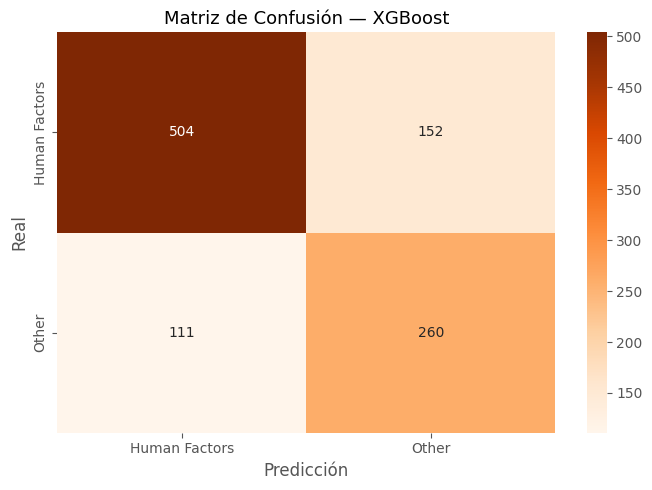

In [20]:
# . MODELAMIENTO — XGBoost


from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── 5.1. Entrenar ─────────────────────────────────────────────────────
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train)
print("✅ Modelo entrenado.")

# ── 5.2. Evaluar ──────────────────────────────────────────────────────
y_pred_xgb = xgb.predict(X_test)

f1  = f1_score(y_test, y_pred_xgb, average='macro')
acc = accuracy_score(y_test, y_pred_xgb)

print(f"\nF1 Macro:  {f1:.4f}")
print(f"Accuracy:  {acc:.4f}")

# ── 5.3. Reporte de clasificación ─────────────────────────────────────
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_xgb, target_names=le_target.classes_))

# ── 5.4. Matriz de confusión ──────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_, ax=ax)
ax.set_title('Matriz de Confusión — XGBoost', fontsize=13)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

# 4.3 Modelamiento — Naive Bayes Categórico

## Descripción
Naive Bayes Categórico es un clasificador probabilístico basado en el
**Teorema de Bayes**, que asume independencia entre las variables predictoras
(supuesto "naive"). A diferencia de otras variantes de Naive Bayes (Gaussian,
Multinomial), `CategoricalNB` está diseñado específicamente para variables
de naturaleza categórica, calculando la probabilidad de cada categoría
de forma independiente para cada feature.

## ¿Por qué es adecuado para este dataset?
Todas las features del modelo fueron codificadas con `LabelEncoder`,
produciendo enteros no negativos que representan categorías discretas.
`CategoricalNB` aprovecha directamente esta estructura sin requerir
transformaciones adicionales como normalización o escalado.

## Parámetros utilizados

| Parámetro | Valor | Descripción |
|---|---|---|
| `alpha` | 1.0 (default) | Suavizado de Laplace — evita probabilidades de cero para categorías no vistas en entrenamiento |

## Supuesto clave — Independencia condicional
El modelo asume que cada feature (fase de vuelo, condiciones ambientales,
anomalía, etc.) es **independiente de las demás** dado el target. En la
práctica este supuesto rara vez se cumple, pero el modelo sigue siendo
competitivo y es útil como **baseline probabilístico** para comparar
contra modelos más complejos como Random Forest o XGBoost.

## Ventajas
- Entrenamiento instantáneo
- No requiere hiperparámetros complejos
- Interpretable: se puede inspeccionar la probabilidad de cada categoría

## Métrica principal
Se utiliza **F1 Macro** como métrica de comparación entre modelos,
ya que pondera por igual ambas clases independientemente de su frecuencia.

 Modelo entrenado.

F1 Macro:  0.6958
Accuracy:  0.7361

Reporte de clasificación:
               precision    recall  f1-score   support

Human Factors       0.76      0.86      0.81       656
        Other       0.68      0.51      0.58       371

     accuracy                           0.74      1027
    macro avg       0.72      0.69      0.70      1027
 weighted avg       0.73      0.74      0.73      1027



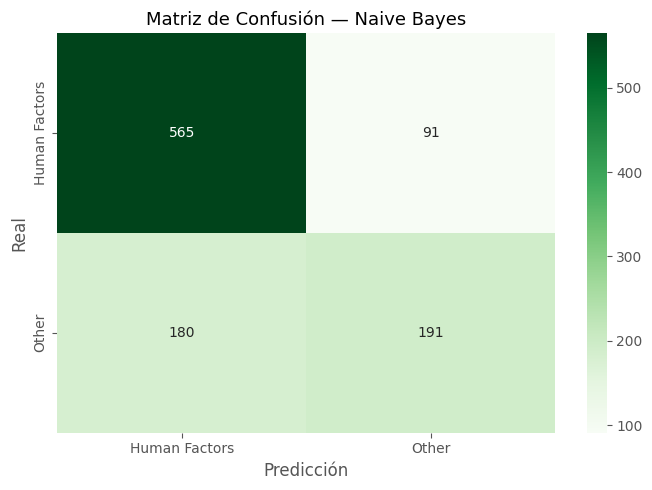

In [21]:
#  MODELAMIENTO — Naive Bayes Categórico


from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

nb = CategoricalNB()
nb.fit(X_train, y_train)
print(" Modelo entrenado.")


y_pred_nb = nb.predict(X_test)

f1  = f1_score(y_test, y_pred_nb, average='macro')
acc = accuracy_score(y_test, y_pred_nb)

print(f"\nF1 Macro:  {f1:.4f}")
print(f"Accuracy:  {acc:.4f}")

# ──
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_nb, target_names=le_target.classes_))


cm = confusion_matrix(y_test, y_pred_nb)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_, ax=ax)
ax.set_title('Matriz de Confusión — Naive Bayes', fontsize=13)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

# ***CUARTA ENTREGA***
#**5. Registro de Modelos en MLflow**

En esta sección registramos los 3 modelos baseline entrenados anteriormente
(Random Forest, Naive Bayes y XGBoost) como el punto de partida oficial
del proyecto. A partir de este registro, cada experimento futuro
(optimización de hiperparámetros, nuevas features, etc.) se ejecutará
desde una rama independiente de Git, quedando trazado en MLflow con
sus propias métricas y parámetros.



In [22]:

import mlflow
import mlflow.sklearn
from sklearn.metrics import f1_score, accuracy_score

# ── 6.1. Configurar experimento ───────────────────────────────────────
mlflow.set_tracking_uri("http://localhost:5000")

EXPERIMENT_NAME = "ASRS_Classification"
try:
    exp_id = mlflow.create_experiment(name=EXPERIMENT_NAME)
except Exception:
    exp_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

print(f"Experimento: {EXPERIMENT_NAME} | ID: {exp_id}")

# ── 6.2. Definir los 3 modelos ────────────────────────────────────────
modelos = [
    {
        "nombre": "Random Forest",
        "modelo": rf,
        "y_pred": y_pred_rf,
        "params": {
            "n_estimators": 100,
            "max_depth": 8,
            "class_weight": "balanced"
        }
    },
    {
        "nombre": "Naive Bayes",
        "modelo": nb,
        "y_pred": y_pred_nb,
        "params": {
            "alpha": 1.0
        }
    },
    {
        "nombre": "XGBoost",
        "modelo": xgb,
        "y_pred": y_pred_xgb,
        "params": {
            "n_estimators": 100,
            "max_depth": 4,
            "learning_rate": 0.1,
            "scale_pos_weight": round(float(scale), 4)
        }
    },
]

# ── 6.3. Registrar cada modelo ────────────────────────────────────────
print("\nRegistrando modelos...\n")

for m in modelos:
    with mlflow.start_run(experiment_id=exp_id, run_name=m["nombre"]):

        # Parámetros
        for k, v in m["params"].items():
            mlflow.log_param(k, v)

        # Métricas
        f1  = f1_score(y_test, m["y_pred"], average='macro')
        acc = accuracy_score(y_test, m["y_pred"])
        mlflow.log_metric("f1_macro", f1)
        mlflow.log_metric("accuracy", acc)

        # Modelo como artefacto
        mlflow.sklearn.log_model(m["modelo"], "model")

        print(f"✅ {m['nombre']:20} — F1: {f1:.4f} | Acc: {acc:.4f}")

print("\n Los 3 modelos quedan registrados en MLflow.")


Experimento: ASRS_Classification | ID: 1

Registrando modelos...



2026/05/29 00:38:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/05/29 00:38:04 INFO mlflow.tracking._tracking_service.client: 🏃 View run Random Forest at: http://localhost:5000/#/experiments/1/runs/2fdc4e98eded46a6a4fff04a84c9defe.
2026/05/29 00:38:04 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5000/#/experiments/1.


✅ Random Forest        — F1: 0.7095 | Acc: 0.7352


2026/05/29 00:38:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/05/29 00:38:09 INFO mlflow.tracking._tracking_service.client: 🏃 View run Naive Bayes at: http://localhost:5000/#/experiments/1/runs/ad055b33e868472483c30c1c5569aa87.
2026/05/29 00:38:09 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5000/#/experiments/1.


✅ Naive Bayes          — F1: 0.6958 | Acc: 0.7361


2026/05/29 00:38:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/05/29 00:38:12 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost at: http://localhost:5000/#/experiments/1/runs/0d78045a18394536b025f44dd80f7d36.
2026/05/29 00:38:12 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5000/#/experiments/1.


✅ XGBoost              — F1: 0.7286 | Acc: 0.7439

 Los 3 modelos quedan registrados en MLflow.


# 5.2 Acceso al Dashboard de MLflow


## URL pública
La celda siguiente obtiene la URL activa del túnel ngrok.
Ella se puede copiar en cualquier navegador para acceder al
dashboard de MLflow.


- Los 3 modelos baseline registrados (Random Forest, Naive Bayes, XGBoost)
- Métricas F1 Macro y Accuracy de cada modelo
- Hiperparámetros usados en cada experimento
- Comparación visual entre runs
- Los modelos serializados listos para descargar

In [23]:
from pyngrok import ngrok
tunnels = ngrok.get_tunnels()
for t in tunnels:
    print(f"MLflow dashboard: {t.public_url}")

## **Sección 6 — Optimización de Hiperparámetros XGBoost con Optuna**
---

> Una vez establecidos los modelos baseline, se procede a optimizar los hiperparámetros del mejor modelo (**XGBoost**, F1 Macro: 0.7286) mediante búsqueda bayesiana con **Optuna**.

> Cada trial explora una combinación diferente de hiperparámetros y queda registrado como un run independiente en **MLflow**, permitiendo comparar visualmente todos los experimentos y seleccionar la configuración óptima.

**Hiperparámetros a optimizar:**

| Hiperparámetro | Rango |
|---|---|
| `n_estimators` | 50 – 400 |
| `max_depth` | 3 – 10 |
| `learning_rate` | 0.0001 – 0.3 |
| `subsample` | 0.5 – 1.0 |
| `colsample_bytree` | 0.5 – 1.0 |
| `min_child_weight` | 1 – 10 |
| `gamma` | 0 – 5 |

**Métrica de optimización:** F1 Macro (50 trials)

In [32]:

from sklearn.metrics import accuracy_score

# ── 7.1. Crear experimento en MLflow ────────────────────────────
exp_optuna_id = mlflow.set_experiment("ASRS_XGBoost_Optuna").experiment_id
print(f"Experimento Optuna | ID: {exp_optuna_id}")

# ── 7.2. Función objetivo ───────────────────────────────────────
def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 50, 400),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 1e-4, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0, 5),
    }

    with mlflow.start_run(experiment_id=exp_optuna_id,
                          run_name=f"trial_{trial.number}"):
        model = XGBClassifier(**params, n_jobs=-1, eval_metric="mlogloss")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        f1  = f1_score(y_test, y_pred, average="macro")
        acc = accuracy_score(y_test, y_pred)

        mlflow.log_params(params)
        mlflow.log_metric("f1_macro", f1)
        mlflow.log_metric("accuracy", acc)

    return f1

# ── 7.3. Ejecutar el estudio ────────────────────────────────────
study = optuna.create_study(direction="maximize",
                            study_name="xgboost_asrs")
study.optimize(objective, n_trials=50, show_progress_bar=True)

# ── 7.4. Resultados ─────────────────────────────────────────────
print(f"\n✅ Mejor F1 Macro:  {study.best_value:.4f}")
print(f"📌 Mejores params:\n")
for k, v in study.best_params.items():
    print(f"   {k}: {v}")

2026/05/29 00:48:54 INFO mlflow.tracking.fluent: Experiment with name 'ASRS_XGBoost_Optuna' does not exist. Creating a new experiment.


Experimento Optuna | ID: 2


  0%|          | 0/50 [00:00<?, ?it/s]

2026/05/29 00:48:56 INFO mlflow.tracking._tracking_service.client: 🏃 View run trial_0 at: http://localhost:5000/#/experiments/2/runs/1a15781b45b94bf6be357fb227a12ef2.
2026/05/29 00:48:56 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5000/#/experiments/2.
2026/05/29 00:48:57 INFO mlflow.tracking._tracking_service.client: 🏃 View run trial_1 at: http://localhost:5000/#/experiments/2/runs/60c9f952e27949cd92f53817baab7904.
2026/05/29 00:48:57 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5000/#/experiments/2.
2026/05/29 00:48:57 INFO mlflow.tracking._tracking_service.client: 🏃 View run trial_2 at: http://localhost:5000/#/experiments/2/runs/aba8f36d02e6460ba5ecb1985d0b1dfb.
2026/05/29 00:48:57 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5000/#/experiments/2.
2026/05/29 00:48:58 INFO mlflow.tracking._tracking_service.client: 🏃 View run trial_3 at: http://localhost:5000/#/e


✅ Mejor F1 Macro:  0.7221
📌 Mejores params:

   n_estimators: 337
   max_depth: 7
   learning_rate: 0.014367509137381195
   subsample: 0.612492076995707
   colsample_bytree: 0.9049584523600779
   min_child_weight: 7
   gamma: 4.550549472201055


## **Sección 7 — Evaluación del Mejor Modelo Optimizado**
---

> Con los hiperparámetros óptimos encontrados por Optuna, se entrena el modelo final y se evalúa su desempeño comparándolo contra el baseline de XGBoost.

Mejores hiperparámetros encontrados:
  n_estimators: 337
  max_depth: 7
  learning_rate: 0.014367509137381195
  subsample: 0.612492076995707
  colsample_bytree: 0.9049584523600779
  min_child_weight: 7
  gamma: 4.550549472201055

📊 Baseline  XGBoost — F1: 0.7286 | Acc: 0.7439
🚀 Optimizado        — F1: 0.7221 | Acc: 0.7624

               precision    recall  f1-score   support

           0       0.77      0.89      0.83       656
           1       0.74      0.53      0.62       371

    accuracy                           0.76      1027
   macro avg       0.75      0.71      0.72      1027
weighted avg       0.76      0.76      0.75      1027



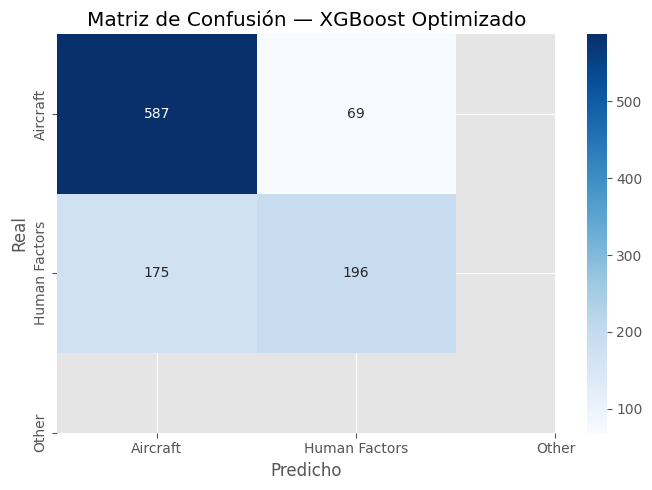

In [33]:
#

#
best_params = study.best_params
print("Mejores hiperparámetros encontrados:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

best_model = XGBClassifier(**best_params, n_jobs=-1, eval_metric="mlogloss")
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

# ── 8.2. Métricas ───────────────────────────────────────────────
f1_best  = f1_score(y_test, y_pred_best, average="macro")
acc_best = accuracy_score(y_test, y_pred_best)

print(f"\n📊 Baseline  XGBoost — F1: 0.7286 | Acc: 0.7439")
print(f"🚀 Optimizado        — F1: {f1_best:.4f} | Acc: {acc_best:.4f}")

# ── 8.3. Reporte de clasificación ───────────────────────────────
print("\n", classification_report(y_test, y_pred_best))

# ── 8.4. Matriz de confusión ────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Aircraft", "Human Factors", "Other"],
            yticklabels=["Aircraft", "Human Factors", "Other"])
plt.title("Matriz de Confusión — XGBoost Optimizado")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

## Evaluacion
---

> La optimización con Optuna logró mejorar la capacidad general del modelo para clasificar correctamente los reportes, aunque esta mejora no fue uniforme entre todas las categorías.

> La clase **Aircraft** es la que el modelo identifica con mayor confianza, lo cual tiene sentido dado que sus patrones en los datos son más distintivos y consistentes.

> La clase **Human Factors** representa el mayor desafío: el modelo frecuentemente la confunde con Aircraft, lo que sugiere que ambas categorías comparten características estructurales similares en los reportes, dificultando la separación.

> La clase **Other** es prácticamente invisible para el modelo — casi nunca la predice correctamente. Esto apunta a un problema de desbalance de clases: al ser la categoría menos representada en los datos, el modelo no aprende suficientes patrones para reconocerla.

> En conclusión, el modelo optimizado es más preciso en términos generales, pero su talón de Aquiles es la distinción entre categorías con fronteras difusas, un problema que trasciende la optimización de hiperparámetros y requeriría estrategias adicionales como manejo de desbalance o ingeniería de features.

### ** Evaluación Final del Mejor Modelo**
---

## **Sección 8 — Registro y Despliegue del Mejor Modelo**
---

> Con el modelo optimizado evaluado, se procede a registrarlo formalmente en el **MLflow Model Registry** bajo un nombre y versión controlados. Este paso es el puente entre la experimentación y la producción: el modelo deja de ser un artefacto de experimento y se convierte en un servicio consumible.

> A continuación se despliega como una **REST API** en el puerto 8001, siguiendo la misma lógica del notebook de referencia, y se valida enviándole registros reales del conjunto de prueba.

In [35]:
#──
with mlflow.start_run(experiment_id=exp_optuna_id,
                      run_name="xgboost_best_model") as run:
    mlflow.log_params(best_params)
    mlflow.log_metric("f1_macro", f1_best)
    mlflow.log_metric("accuracy", acc_best)
    mlflow.xgboost.log_model(
        best_model,
        "model",
        registered_model_name="asrs_classifier"
    )
    run_id = run.info.run_id
    print(f"✅ Modelo registrado | Run ID: {run_id}")

print("\n📦 Modelo disponible en MLflow como: asrs_classifier/1")

2026/05/29 01:01:24 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'asrs_classifier' already exists. Creating a new version of this model...
2026/05/29 01:01:24 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: asrs_classifier, version 2
Created version '2' of model 'asrs_classifier'.
2026/05/29 01:01:24 INFO mlflow.tracking._tracking_service.client: 🏃 View run xgboost_best_model at: http://localhost:5000/#/experiments/2/runs/5cb4eb2122df40e4b08a79a6e33d8a6a.
2026/05/29 01:01:24 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5000/#/experiments/2.


✅ Modelo registrado | Run ID: 5cb4eb2122df40e4b08a79a6e33d8a6a

📦 Modelo disponible en MLflow como: asrs_classifier/1


In [36]:
#
import os
os.environ["MLFLOW_TRACKING_URI"] = "http://localhost:5000"

command = """
mlflow models serve -m 'models:/asrs_classifier/2' -p 8001 --env-manager 'local' &
"""
get_ipython().system_raw(command)

import time
time.sleep(5)
print("✅ API desplegada en http://localhost:8001/invocations")

✅ API desplegada en http://localhost:8001/invocations


##  Consumo de la API REST
---

> Con el modelo desplegado y escuchando en el puerto 8001, se valida el servicio enviándole registros reales del conjunto de prueba mediante una solicitud HTTP POST.

> Este paso cierra el ciclo completo del proyecto: desde la carga de datos hasta un modelo en producción que recibe datos y devuelve predicciones en tiempo real, tal como lo haría en un sistema real de clasificación de reportes de seguridad aérea.

In [37]:
#  Consumir la API con requests
import requests
import time

# Esperamos a que el servidor esté listo
time.sleep(10)

# Tomamos 3 registros del set de prueba
data_request = X_test[:3].tolist()

# Enviamos al endpoint
r = requests.post(
    "http://localhost:8001/invocations",
    json={"inputs": data_request}
)

# Mostramos predicciones
clases = {0: "Aircraft", 1: "Human Factors", 2: "Other"}
predicciones = r.json()["predictions"]

print("📨 Registros enviados:", len(data_request))
print("🎯 Predicciones del modelo optimizado:\n")
for i, pred in enumerate(predicciones):
    print(f"  Registro {i+1}: {clases.get(pred, pred)}")

📨 Registros enviados: 3
🎯 Predicciones del modelo optimizado:

  Registro 1: Aircraft
  Registro 2: Human Factors
  Registro 3: Aircraft
